In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
# from Q_Seg_main.qseg.dwave_utils import *
from qseg import *
import cv2
from my_segmentation import *
from sklearn.metrics import accuracy_score, f1_score, jaccard_score, recall_score, precision_score
import time
import copy
import pandas as pd
from itertools import product

In [2]:
# load new images
path = "datasets/spheroidite_particles/"
image_files = [f for f in os.listdir(path+"image_patches/")]
mask_files = [f for f in os.listdir(path+"label_patches/")]

images = [cv2.imread(path+"image_patches/"+f, cv2.IMREAD_GRAYSCALE) for f in image_files]
masks = [cv2.imread(path+"label_patches/"+f, cv2.IMREAD_GRAYSCALE) for f in mask_files]

In [29]:
def optimize_pipeline(raw_image, mask):
    # Match sequential step 1: Sharpen image first
    image = sharpnening(raw_image)
    dim = image.shape[0]

    # Construct base graph once from sharpened image
    G_base, dmin, dmax = construct_graph(image)
    
    thresholds = [0, 0.1, 0.2]
    k_values = [0, 0.1, 0.2]  
    
    results = []
    
    for th, k in product(thresholds, k_values):
        start_time = time.time() #

        G = copy.deepcopy(G_base)
        H, I, important, redundant = importance_sampling(
            G, threshold=th, node_size=0.1, show_graph=False)
        if k > 0:
            sampled_nodes = random_sampling(I, copy.deepcopy(redundant), k=k, seed=0)
            I.add_nodes_from(sampled_nodes)
        I = update_edgeweights(I, image, dim, dmin, dmax, close_loop='rc', mode=1)
        
        # solve QUBO
        bqm, sampleset = annealer_solver_sa(I)
        sampleset_first = sampleset.first.sample
        
        processing_time = time.time() - start_time # 
        
        start_time = time.time() ##
        # label propagation
        metrics_df = label_propagation_graph(I, sampleset_first, dim, mask)
        labeling_time = time.time() - start_time ##
        
        
        results.append({
            'thresholds':th,
            'k_values':k,
            'Accuracy': metrics_df['accuracy'].iloc[0],
            'IoU': metrics_df['iou'].iloc[0],
            'Precision': metrics_df['precision'].iloc[0],
            'Recall': metrics_df['recall'].iloc[0],
            'F1': metrics_df['f1'].iloc[0],
            'processing_time': processing_time,
            'labeling_time':labeling_time
        })
        
    df_results = pd.DataFrame(results)
    best_config = df_results.sort_values(by='IoU', ascending=False).iloc[0]

    return best_config

In [30]:
best_config = optimize_pipeline(images[0], masks[0])
df = best_config.to_frame()
df.T

,thresholds,k_values,Accuracy,IoU,Precision,Recall,F1,processing_time,labeling_time
8,0.2,0.2,0.96,0.8,0.914,0.854,0.881,8.114236,2.844331


In [32]:
df = pd.DataFrame(columns=['idx', 'thresholds', 'k', 'Accuracy', 'IoU', 'Precision', 'Recall', 'F1', 'Processing time', 'Labeling time'])

In [33]:
for i in range(len(images)):
    best_config = optimize_pipeline(images[i], masks[i])
    df.loc[len(df)] = [i] + best_config.round(3).tolist()
    
df

,idx,thresholds,k,Accuracy,IoU,Precision,Recall,F1,Processing time,Labeling time
0,0.0,0.2,0.2,0.960,0.801,0.913,0.854,0.881,8.103,2.718
1,1.0,0.1,0.2,0.950,0.788,0.884,0.862,0.872,8.573,2.322
2,2.0,0.1,0.2,0.935,0.769,0.899,0.831,0.860,8.664,2.741
3,3.0,0.2,0.2,0.930,0.742,0.887,0.806,0.839,10.862,2.813
4,4.0,0.2,0.2,0.950,0.805,0.922,0.857,0.886,9.216,2.738
5,5.0,0.1,0.2,0.960,0.822,0.928,0.870,0.896,7.017,2.613
6,6.0,0.1,0.1,0.950,0.770,0.891,0.833,0.859,5.635,2.781
7,7.0,0.2,0.2,0.953,0.775,0.913,0.825,0.862,7.319,2.735
8,8.0,0.0,0.1,0.930,0.772,0.882,0.847,0.863,7.706,2.632
9,9.0,0.0,0.2,0.935,0.788,0.890,0.861,0.874,8.156,2.716


In [39]:
df.to_csv('spherodite_this_work.csv', index=False)

In [40]:
df.describe().loc[['mean', '50%']].round(3)

,idx,thresholds,k,Accuracy,IoU,Precision,Recall,F1,Processing time,Labeling time
mean,9.5,0.08,0.18,0.943,0.780,0.892,0.847,0.867,8.061,2.762
50%,9.5,0.10,0.20,0.942,0.774,0.889,0.847,0.862,8.146,2.740


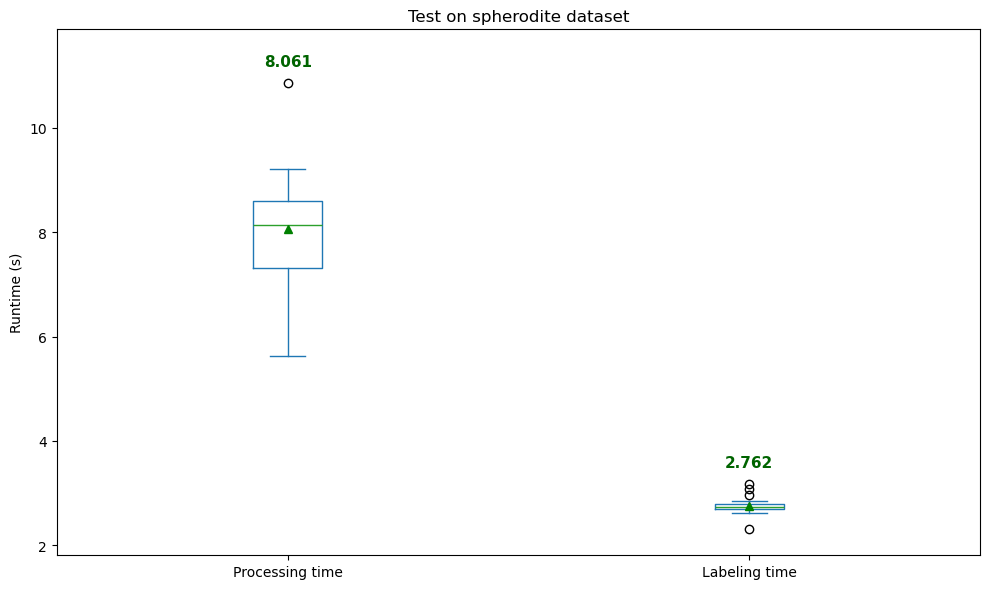

In [41]:
if 'idx' in df.columns:
    df_runtime = df.set_index('idx')
df_runtime = df_runtime[['Processing time', 'Labeling time']]

# 1. Generate boxplot with mean markers
ax = df_runtime.plot(
    kind="box",
    figsize=(10, 6),
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "green",
    },
)

# Offset to lift text above the top whisker/outliers
y_offset = (df_runtime.values.max() - df_runtime.values.min()) * 0.03

# 2. Iterate through columns and place text above each box
for i, col in enumerate(df_runtime.columns, start=1):
    mean_val = df_runtime[col].mean()
    max_val = df_runtime[col].max()  # Positions above the highest point of the column

    ax.text(
        x=i,
        y=max_val + y_offset,
        s=f"{mean_val:.3f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=11,
        color="darkgreen",
        fontweight="bold",
    )

# Adjust y-limit slightly so top text doesn't get clipped by the frame
ax.set_ylim(df_runtime.values.min() - y_offset * 2, df_runtime.values.max() + y_offset * 4)

plt.grid(False)
plt.title("Test on spherodite dataset")
plt.ylabel("Runtime (s)")
plt.tight_layout()
plt.show()

In [ ]:
df.drop(columns=['idx', 'thresholds', 'k', 'Processing time', 'Labeling time'], inplace=True)

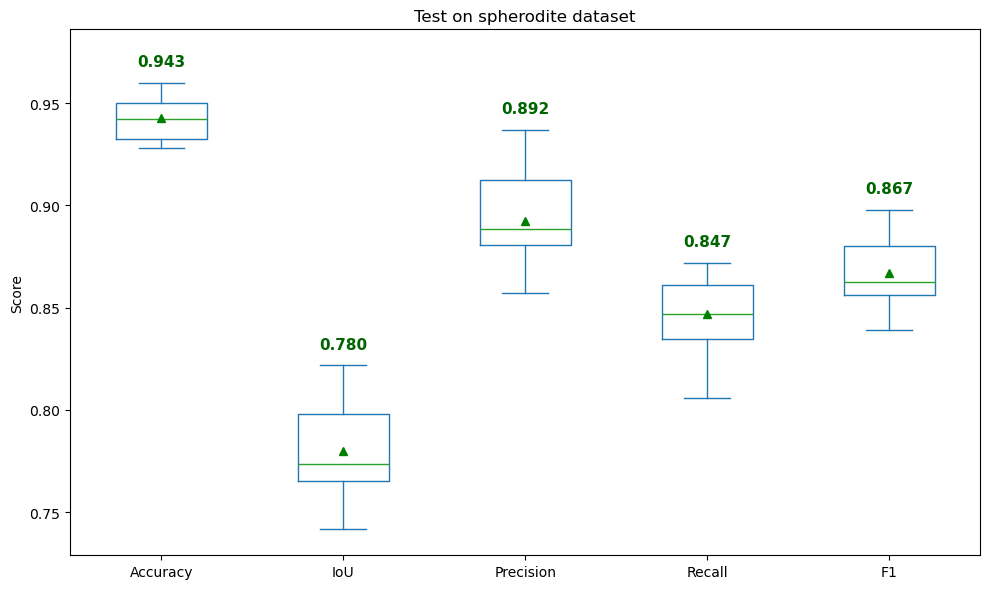

In [45]:
# 1. Generate boxplot with mean markers
ax = df.plot(
    kind="box",
    figsize=(10, 6),
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "green",
    },
)

# Offset to lift text above the top whisker/outliers
y_offset = (df.values.max() - df.values.min()) * 0.03

# 2. Iterate through columns and place text above each box
for i, col in enumerate(df.columns, start=1):
    mean_val = df[col].mean()
    max_val = df[col].max()  # Positions above the highest point of the column

    ax.text(
        x=i,
        y=max_val + y_offset,
        s=f"{mean_val:.3f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=11,
        color="darkgreen",
        fontweight="bold",
    )

# Adjust y-limit slightly so top text doesn't get clipped by the frame
ax.set_ylim(df.values.min() - y_offset * 2, df.values.max() + y_offset * 4)

plt.grid(False)
plt.title("Test on spherodite dataset")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

QUBO w/o sampling

In [3]:
results_qubo = []

for i in range(len(images)):
    sample = sharpnening(images[i])
    dim = sample.shape[0]

    start = time.time()
    # image to graph
    G, dmin, dmax = construct_graph(sample)

    bqm, sampleset = annealer_solver_sa(G)
    sampleset_first = sampleset.first.sample
    end = time.time()
    
    accuracy, iou, precision, recall, f1 = qseg_evaluation(sampleset_first, dim, masks[i])
    
    results_qubo.append({
        'Accuracy': accuracy,
        'IoU': iou,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Runtime': round(end - start, 3)
    })

df_qubo = pd.DataFrame(results_qubo)
df_qubo

,Accuracy,IoU,Precision,Recall,F1,Runtime
0,0.490,0.171,0.633,0.515,0.226,32.932
1,0.493,0.175,0.634,0.518,0.229,32.775
2,0.489,0.176,0.622,0.525,0.230,32.799
3,0.503,0.180,0.625,0.529,0.234,33.157
4,0.509,0.181,0.626,0.530,0.235,32.535
5,0.525,0.186,0.633,0.532,0.239,32.721
6,0.512,0.180,0.635,0.525,0.234,32.024
7,0.457,0.161,0.632,0.504,0.217,33.253
8,0.425,0.153,0.610,0.502,0.210,35.401
9,0.497,0.180,0.620,0.530,0.233,35.235


In [7]:
df_qubo.to_csv('spherodite_qubo.csv', index=False)

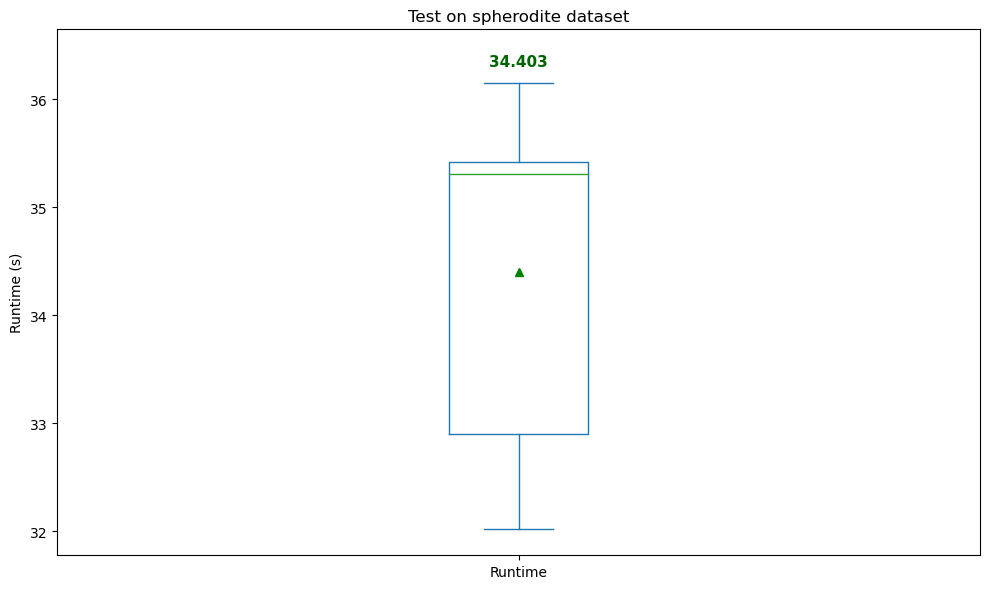

In [8]:
if 'idx' in df_qubo.columns:
    df_qubo = df_qubo.set_index('idx')

df_runtime = df_qubo[['Runtime']]

# 1. Generate boxplot with mean markers
ax = df_runtime.plot(
    kind="box",
    figsize=(10, 6),
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "green",
    },
)

# Offset to lift text above the top whisker/outliers
y_offset = (df_runtime.values.max() - df_runtime.values.min()) * 0.03

# 2. Iterate through columns and place text above each box
for i, col in enumerate(df_runtime.columns, start=1):
    mean_val = df_runtime[col].mean()
    max_val = df_runtime[col].max()  # Positions above the highest point of the column

    ax.text(
        x=i,
        y=max_val + y_offset,
        s=f"{mean_val:.3f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=11,
        color="darkgreen",
        fontweight="bold",
    )

# Adjust y-limit slightly so top text doesn't get clipped by the frame
ax.set_ylim(df_runtime.values.min() - y_offset * 2, df_runtime.values.max() + y_offset * 4)

plt.grid(False)
plt.title("Test on spherodite dataset")
plt.ylabel("Runtime (s)")
plt.tight_layout()
plt.show()

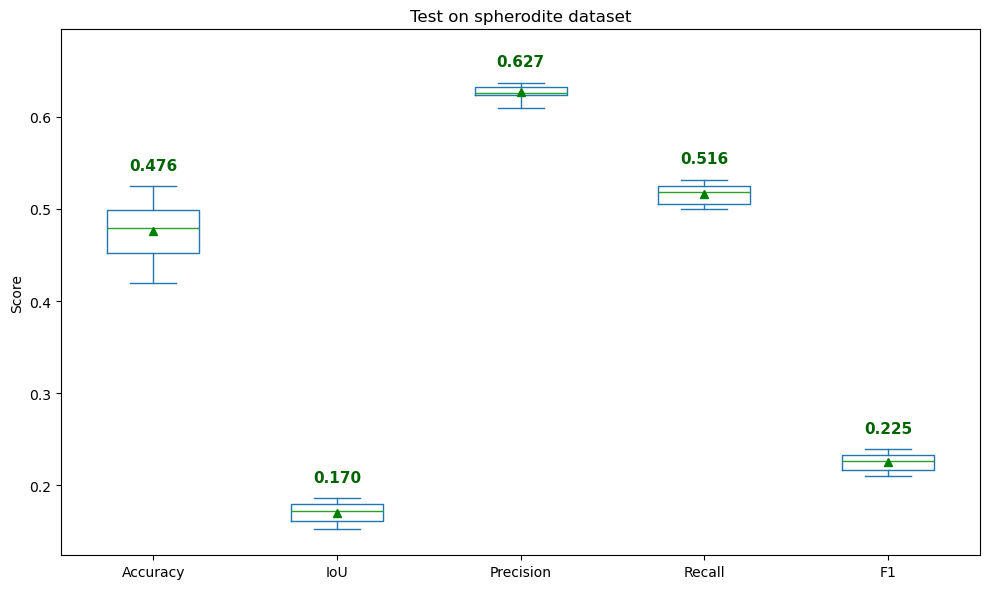

In [14]:
# df_qubo.drop(columns=['Runtime'], inplace=True)

# 1. Generate boxplot with mean markers
ax = df_qubo.plot(
    kind="box",
    figsize=(10, 6),
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "green",
    },
)

# Offset to lift text above the top whisker/outliers
y_offset = (df_qubo.values.max() - df_qubo.values.min()) * 0.03

# 2. Iterate through columns and place text above each box
for i, col in enumerate(df_qubo.columns, start=1):
    mean_val = df_qubo[col].mean()
    max_val = df_qubo[col].max()  # Positions above the highest point of the column

    ax.text(
        x=i,
        y=max_val + y_offset,
        s=f"{mean_val:.3f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=11,
        color="darkgreen",
        fontweight="bold",
    )

# Adjust y-limit slightly so top text doesn't get clipped by the frame
ax.set_ylim(df_qubo.values.min() - y_offset * 2, df_qubo.values.max() + y_offset * 4)

plt.grid(False)
plt.title("Test on spherodite dataset")
plt.ylabel("Score")
plt.tight_layout()
plt.show()